# Visualizing Chipotle's Data

This time we are going to pull data directly from the internet.
Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

%matplotlib inline

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv).

### Step 3. Assign it to a variable called chipo.

In [6]:
url = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv'

chipo = pd.read_csv(url, sep = '\t')

### Step 4. See the first 10 entries

In [7]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### Step 5. Create a histogram of the top 5 items bought

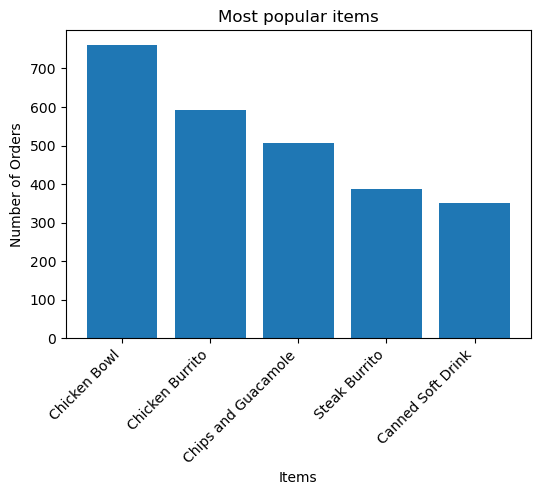

In [10]:
# item_name별로 quantity 합계 구하기
letter_counter = chipo.groupby('item_name')['quantity'].sum()

# 내림차순 정렬 후 상위 5개
top5 = letter_counter.sort_values(ascending=False).head(5)

plt.figure(figsize=(6,4))
plt.bar(top5.index, top5.values, color='#1f77b4')
plt.xlabel('Items')
plt.ylabel('Number of Orders')
plt.title('Most popular items')
plt.xticks(rotation=45, ha='right')
plt.show()

### Step 6. Create a scatterplot with the number of items orderered per order price
#### Hint: Price should be in the X-axis and Items ordered in the Y-axis

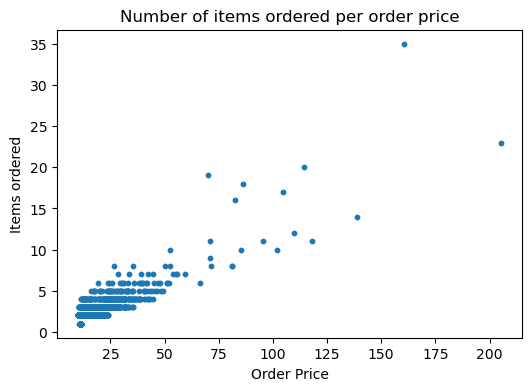

In [11]:
# '$2.39' -> 2.39 로 변환
chipo['item_price'] = chipo['item_price'].str.replace('$', '', regex=False).astype(float)

# order_id 기준으로 총 아이템 개수, 총 가격 합산
orders = chipo.groupby('order_id').agg({'quantity': 'sum', 'item_price': 'sum'})

plt.figure(figsize=(6,4))
plt.scatter(orders['item_price'], orders['quantity'], s=10, color='#1f77b4')
plt.xlabel('Order Price')
plt.ylabel('Items ordered')
plt.title('Number of items ordered per order price')
plt.show()

### Step 7. BONUS: Create a question and a graph to answer your own question.

주문(order) 하나에 들어가는 아이템 개수가 늘어날수록, 1인당 평균 결제 금액 변화

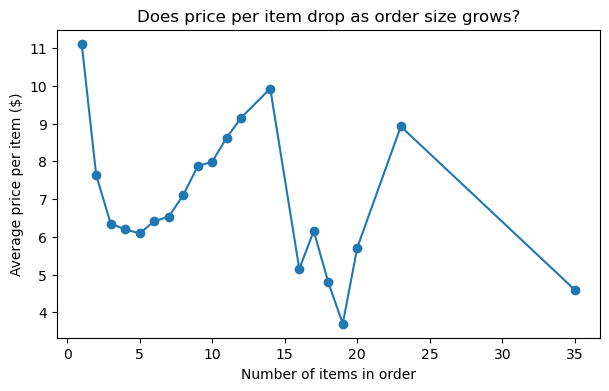

In [12]:
# order_id별로 총 아이템 개수, 총 금액 계산 (이미 있으면 재사용)
orders = chipo.groupby('order_id').agg({'quantity': 'sum', 'item_price': 'sum'})

# 아이템 1개당 평균 금액 계산
orders['price_per_item'] = orders['item_price'] / orders['quantity']

# 아이템 개수(quantity)별로 price_per_item 평균 구하기
avg_price_by_qty = orders.groupby('quantity')['price_per_item'].mean()

plt.figure(figsize=(7,4))
plt.plot(avg_price_by_qty.index, avg_price_by_qty.values, marker='o', color='#1f77b4')
plt.xlabel('Number of items in order')
plt.ylabel('Average price per item ($)')
plt.title('Does price per item drop as order size grows?')
plt.show()